In [1]:
import pandas as pd
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

C:\Users\HP\anaconda3\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\HP\anaconda3\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


# Data Exploration

In [2]:
df.shape

(7043, 21)

In [3]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [6]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df["tenure"].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39], dtype=int64)

In [9]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['0-1yr', '1-2yr', '2-4yr', '4+yrs'])

C:\Users\HP\AppData\Local\Temp\ipykernel_31228\3467076292.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
C:\Users\HP\AppData\Local\Temp\ipykernel_31228\3467076292.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
C:\Users\HP\AppData\Local\Temp\ipykernel_31228\3467076292.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)


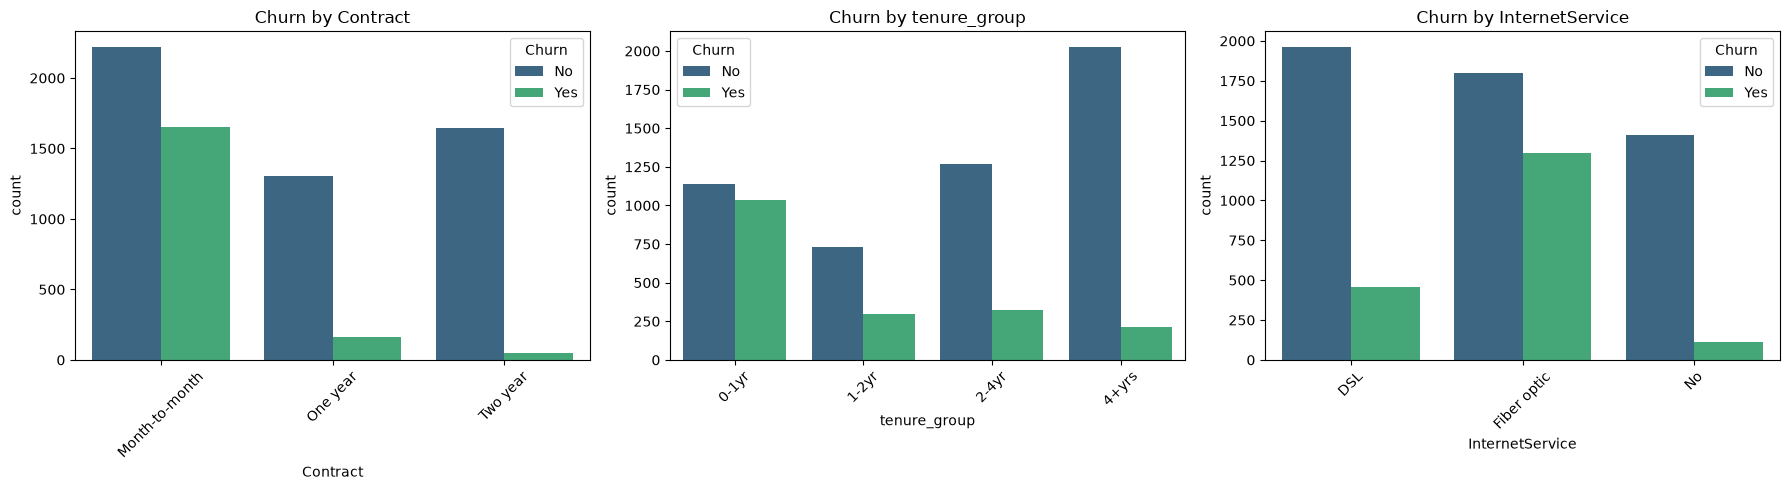

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ["Contract", "tenure_group", "InternetService"]

for i, col in enumerate(features):
    sns.countplot(
        data=df, 
        x=col, 
        hue="Churn", 
        ax=axes[i], 
        palette="viridis"
    )
    axes[i].set_title(f"Churn by {col}")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [12]:
df = df.drop(columns=["customerID"])

In [13]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [14]:
from sklearn.preprocessing import StandardScaler
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=["Churn", "tenure_group"], errors="ignore")
y = df["Churn"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train["TotalCharges"] = X_train["TotalCharges"].fillna(0)
X_test["TotalCharges"] = X_test["TotalCharges"].fillna(0)

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

model = LogisticRegression(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

print("Pipeline executed successfully and model is trained!")

Pipeline executed successfully and model is trained!


In [16]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [17]:
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [18]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score")
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score
ROC-AUC Score: 0.8416


In [19]:
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix
[[748 287]
 [ 81 293]]


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)
print(f"Random Forest ROC-AUC Score: {rf_roc_auc:.4f}")

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409

Random Forest ROC-AUC Score: 0.8254


C:\Users\HP\AppData\Local\Temp\ipykernel_31228\3155963851.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x="Importance", y="Feature", palette="viridis")


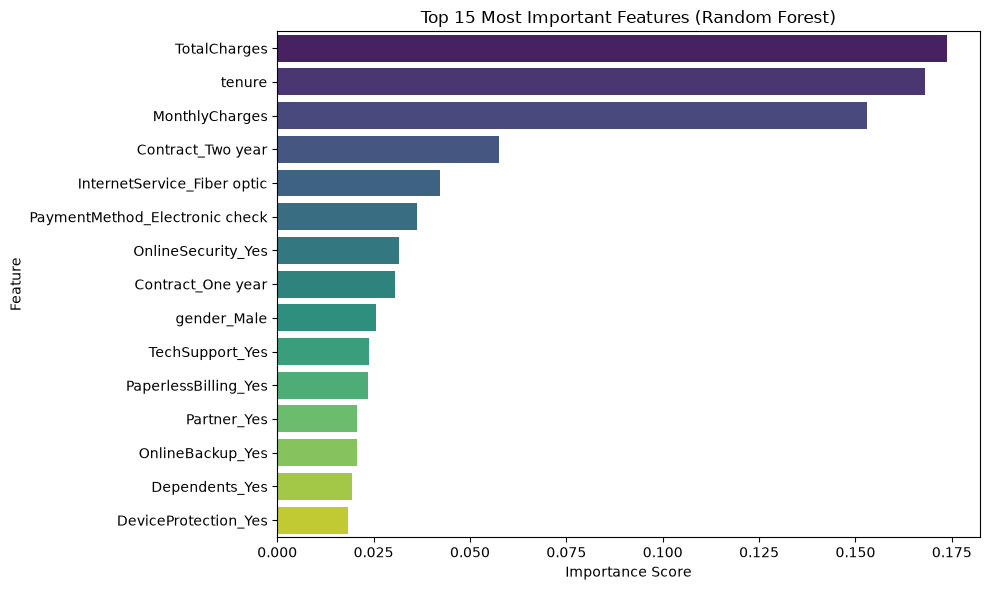

In [21]:
importances = pd.DataFrame({"Feature": X_train.columns, "Importance": rf_model.feature_importances_})

importances = importances.sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x="Importance", y="Feature", palette="viridis")

plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from xgboost import XGBClassifier

num_negatives = sum(y_train == 0)
num_positives = sum(y_train == 1)
calculated_weight = num_negatives / num_positives

print(f"Calculated scale_pos_weight: {calculated_weight:.4f}")

xgb_model = XGBClassifier(
    scale_pos_weight=calculated_weight, 
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)
y_pred_proba_lr = model.predict_proba(X_test)[:, 1]

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

comparison_data = {
    "Metric": ["Accuracy", "Precision (Churn)", "Recall (Churn)", "F1-Score (Churn)", "ROC-AUC"],
    "Logistic Regression (Baseline)": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr, pos_label=1),
        recall_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_lr, pos_label=1),
        roc_auc_score(y_test, y_pred_proba_lr)
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf, pos_label=1),
        recall_score(y_test, y_pred_rf, pos_label=1),
        f1_score(y_test, y_pred_rf, pos_label=1),
        roc_auc_score(y_test, y_pred_proba_rf)
    ],
    "XGBoost (Weighted)": [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb, pos_label=1),
        recall_score(y_test, y_pred_xgb, pos_label=1),
        f1_score(y_test, y_pred_xgb, pos_label=1),
        roc_auc_score(y_test, y_pred_proba_xgb)
    ]
}

df_compare = pd.DataFrame(comparison_data).set_index("Metric")
print("\n--- Final Model Comparison Table ---")
print(df_compare.round(4))


Calculated scale_pos_weight: 2.7686

--- Final Model Comparison Table ---
                   Logistic Regression (Baseline)  Random Forest  \
Metric                                                             
Accuracy                                   0.7388         0.7708   
Precision (Churn)                          0.5052         0.5603   
Recall (Churn)                             0.7834         0.6337   
F1-Score (Churn)                           0.6143         0.5947   
ROC-AUC                                    0.8416         0.8254   

                   XGBoost (Weighted)  
Metric                                 
Accuracy                       0.7622  
Precision (Churn)              0.5412  
Recall (Churn)                 0.6845  
F1-Score (Churn)               0.6045  
ROC-AUC                        0.8264  


In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    scale_pos_weight=calculated_weight,
    random_state=42,
    eval_metric="logloss"
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

xgb_model_tuned = grid_search.best_estimator_

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV ROC-AUC: 0.8510819949334172


In [24]:
y_pred_xgb_tuned = xgb_model_tuned.predict(X_test)
y_pred_proba_xgb_tuned = xgb_model_tuned.predict_proba(X_test)[:, 1]

print("Tuned XGBoost:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("Precision:", precision_score(y_test, y_pred_xgb_tuned, pos_label=1))
print("Recall:", recall_score(y_test, y_pred_xgb_tuned, pos_label=1))
print("F1:", f1_score(y_test, y_pred_xgb_tuned, pos_label=1))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb_tuned))

Tuned XGBoost:
Accuracy: 0.7423704755145494
Precision: 0.5093378607809848
Recall: 0.8021390374331551
F1: 0.6230529595015576
ROC-AUC: 0.8461869332713323


In [25]:
pip install shap


  Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl.metadata (59 kB)
Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl (15.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.2 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.5 which is incompatible.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


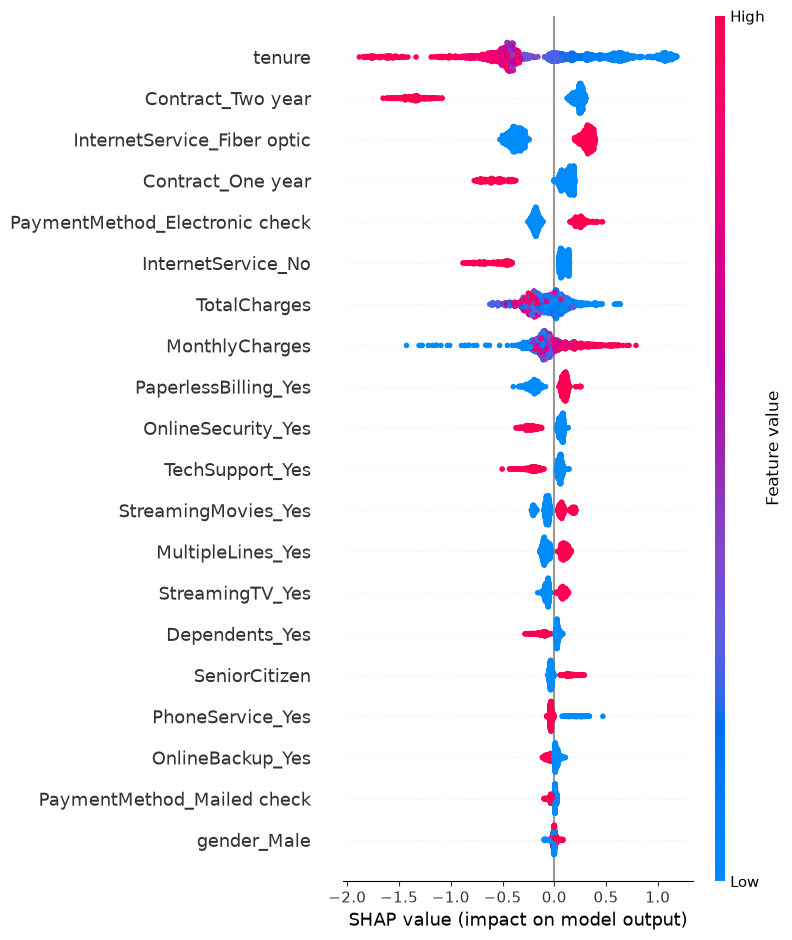

In [27]:
import shap 
explainer = shap.TreeExplainer(xgb_model_tuned)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [30]:
import joblib
joblib.dump(xgb_model_tuned, "churn_model.pkl")
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [31]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']